In [1]:
import numpy as np
from matplotlib import pyplot as plt

from pyloki.config import ParamLimits, PulsarSearchConfig
from pyloki.detection import thresholding
from pyloki.ffa import DynamicProgramming
from pyloki.periodogram import PruningStatsPlotter, ScatteredPeriodogram
from pyloki.prune import prune_dyp_tree
from pyloki.simulation.pulse import PulseSignalConfig

tobs = 2147.483648


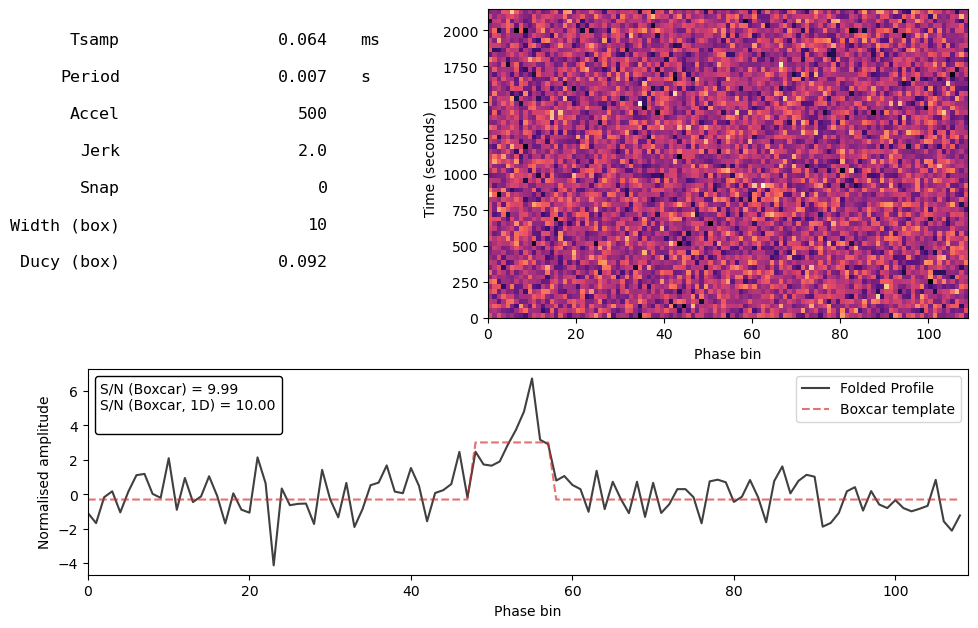

In [2]:
pulsar_period = 0.007
dt = 64e-6
accel = 500
jerk = 2.0
nsamps = 2**25
mod_kwargs = {"acc": accel, "jerk": jerk}
cfg = PulseSignalConfig(
    period=pulsar_period,
    dt=dt,
    nsamps=nsamps,
    snr=10.0,
    ducy=0.1,
    mod_kwargs=mod_kwargs,
)
print(f"tobs = {cfg.tobs}")
tim_data = cfg.generate(shape="gaussian")
tim_data.plot_fold(cfg.freq, cfg.fold_bins, mod_kwargs=mod_kwargs)
plt.show()

In [3]:
eta = 1
nbins = 64
p = ParamLimits.from_upper([jerk, accel, cfg.freq], (-2.0 * jerk, jerk * 2.0), cfg.tobs)
print(f"Param limits: {p.limits}")
bseg_brute = cfg.nsamps // 8192
bseg_ffa = cfg.nsamps // 128

search_cfg = PulsarSearchConfig(
    nsamps=cfg.nsamps,
    tsamp=cfg.dt,
    nbins=nbins,
    eta=eta,
    param_limits=p.limits,
    bseg_brute=bseg_brute,
    bseg_ffa=bseg_ffa,
    prune_poly_order=3,
    ducy_max=0.2,
    wtsp=1.5,
    use_fourier=True,
    use_conservative_tile=False,
    branch_max=32,
)
dyp = DynamicProgramming(tim_data, search_cfg)
dyp.initialize()
dyp.execute()

Param limits: [[-4.00000000e+00  4.00000000e+00]
 [-3.79496730e+03  4.79496730e+03]
 [ 1.41502532e+02  1.44211753e+02]]


2026-04-05 02:22:15 INFO     - pyloki.ffa - FFA initialize: Grid sizes: [3.46195593e+08 7.56275812e+06             
                             1.19209290e-01]

2026-04-05 02:22:18 INFO     - pyloki.ffa - ffa level:  0, leaves: 4.46, fold dims: (8192, 1, 1, 22, 2, 33)

                    INFO     - pyloki.ffa - ffa_initialize finished, Elapsed time: 3.138 seconds

Output()

...

                    INFO     - pyloki.ffa - ffa level:  4, leaves:  8.50, fold dims: (512, 1, 1, 363, 2, 33)

                    INFO     - pyloki.ffa - ffa level:  5, leaves:  9.51, fold dims: (256, 1, 1, 727, 2, 33)

                    INFO     - pyloki.ffa - ffa level:  6, leaves: 12.51, fold dims: (128, 1, 4, 1454, 2, 33)

                    INFO     - pyloki.ffa - FFA complete: Grid sizes: [1.32063138e+03 1.84637650e+03               
                             1.86264515e-03]

                    INFO     - pyloki.ffa - ffa_execute finished, Elapsed time: 4.084 seconds

In [4]:
branching_pattern = search_cfg.generate_branching_pattern(kind="taylor", ref_seg=0)
branching_pattern

array([8.        , 3.        , 2.        , 3.        , 1.        ,
       3.        , 2.        , 3.        , 2.01375516, 1.4897541 ,
       1.        , 1.        , 1.        , 9.        , 2.        ,
       1.        , 1.        , 1.        , 1.        , 3.        ,
       1.        , 1.        , 1.        , 1.        , 3.        ,
       1.        , 1.        , 1.        , 2.01375516, 1.4897541 ,
       2.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 3.        , 3.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 3.        , 2.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.     

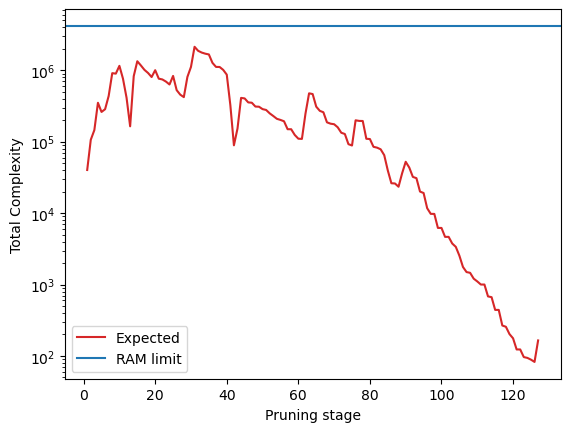

In [5]:
thresholds = np.array([2.2, 2.2, 2.5, 2.5, 2.6, 3.1, 3. , 3.1, 3.4, 3.2, 3.4, 3.6, 3.9,
       4. , 3.9, 3.8, 3.8, 3.7, 3.7, 4.2, 4.2, 3.9, 3.9, 3.9, 4.4, 4.5,
       4.4, 4.3, 4.2, 4.2, 4.1, 4.2, 4.1, 4. , 3.9, 4.2, 4.2, 3.8, 4.1,
       4.2, 4.7, 5.1, 5.2, 5.1, 4.9, 5. , 4.8, 4.9, 4.7, 4.8, 4.7, 4.8,
       4.8, 4.8, 4.7, 4.7, 4.9, 4.6, 4.9, 4.9, 4.7, 5. , 4.9, 4.8, 5.1,
       5.1, 5. , 5.2, 5.1, 5. , 5.1, 5.2, 5.1, 5.3, 5.2, 5.3, 5.3, 5. ,
       5.5, 5.3, 5.5, 5.4, 5.4, 5.5, 5.7, 5.8, 5.6, 5.7, 5.8, 5.7, 5.8,
       5.9, 5.8, 6. , 5.9, 6.1, 6.1, 5.9, 6.2, 5.9, 6.2, 5.8, 6.2, 6.2,
       6.3, 6.4, 6.4, 6.3, 6.4, 6.4, 6.4, 6. , 6.5, 6.4, 6.6, 6.3, 6.7,
       6.6, 6.7, 6.7, 6.8, 6.4, 6.8, 6.7, 6.7, 6.7, 6.3])
thresh_state = thresholding.evaluate_scheme(
    thresholds,
    branching_pattern,
    ref_ducy=0.1,
    nbins=64,
    ntrials=1024,
    snr_final=10.0,
    ducy_max=0.2,
    wtsp=1.5,
)
x = np.arange(1, len(branching_pattern) + 1)
plt.semilogy(
    x,
    np.array(thresh_state.get_info("complexity")) * dyp.nparam_vol,
    label="Expected",
    c="tab:red",
)
plt.axhline(2**22, label="RAM limit", c="tab:blue")
plt.xlabel("Pruning stage")
plt.ylabel("Total Complexity")
plt.legend()
plt.show()

In [6]:
result_file = prune_dyp_tree(
    dyp,
    thresholds,
    n_runs=16,
    max_sugg=2**22,
    outdir="pruning_results/jerk_test/",
    file_prefix="test_jerk",
    poly_basis="taylor",
    n_workers=4,
)

2026-04-05 02:23:10 INFO     - pyloki.prune - Starting Pruning for 16 runs, with 4 workers

Output()

2026-04-05 02:23:17 INFO     - worker_008 - Initializing pruning run with ref segment: 8

                    INFO     - worker_000 - Initializing pruning run with ref segment: 0

                    INFO     - worker_016 - Initializing pruning run with ref segment: 16

...

                    INFO     - worker_101 - Pruning time: Total: 70.6s (score: 44% | shift_add: 19% | branch: 17% |
                             batch_add: 8%)

2026-04-05 02:28:10 INFO     - worker_127 - Pruning run complete for ref segment: 127

                    INFO     - worker_127 - Pruning stats: Score: 7.81, Leaves: 7.74

                    INFO     - worker_127 - Pruning time: Total: 56.7s (score: 45% | shift_add: 19% | branch: 17% |
                             batch_add: 8%)

2026-04-05 02:28:12 INFO     - pyloki.prune - Pruning complete. Results saved to                                   
                             pruning_results/jerk_test/test_jerk_pruning_nstages_128_results.h5

In [7]:
pgram = ScatteredPeriodogram.load(result_file)
print(
    f"True params, j: {cfg.mod_kwargs['jerk']:.3f}, a: {cfg.mod_kwargs['acc']:.3f}, f: {cfg.freq:.10f}",
)
print(pgram.get_summary_cands(10, run_id=None))

True params, j: 2.000, a: 500.000, f: 142.8571428571
Top candidates:
dparams: djerk: 0.001213714096, daccel: 0.2100912312, dfreq: 1.455191523e-05
Run: 067_09, S/N: 9.32, jerk: 2.0007, accel: 500.08, freq: 142.857153
Run: 067_09, S/N: 9.29, jerk: 2.0007, accel: 500.08, freq: 142.857167
Run: 067_09, S/N: 9.24, jerk: 2.0007, accel: 500.08, freq: 142.857197
Run: 067_09, S/N: 9.21, jerk: 2.0007, accel: 500.08, freq: 142.857182
Run: 067_09, S/N: 9.18, jerk: 2.0007, accel: 499.87, freq: 142.857169
Run: 067_09, S/N: 9.15, jerk: 2.0007, accel: 499.87, freq: 142.857155
Run: 059_08, S/N: 9.14, jerk: 1.9975, accel: 500.25, freq: 142.857058
Run: 067_09, S/N: 9.12, jerk: 2.0007, accel: 499.87, freq: 142.857140
Run: 067_09, S/N: 9.09, jerk: 2.0007, accel: 499.87, freq: 142.857184
Run: 067_09, S/N: 9.06, jerk: 2.0019, accel: 500.22, freq: 142.857157


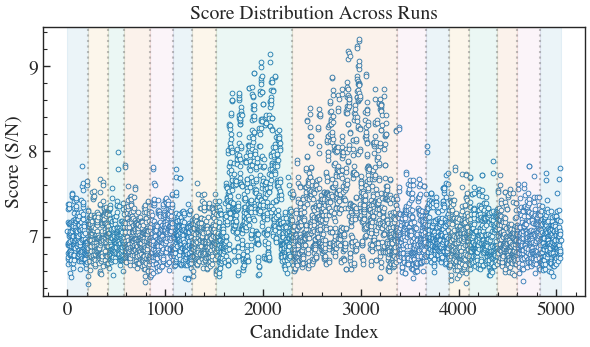

In [8]:
pgram.plot_scores(kind="scatter", run_id=None)
plt.show()

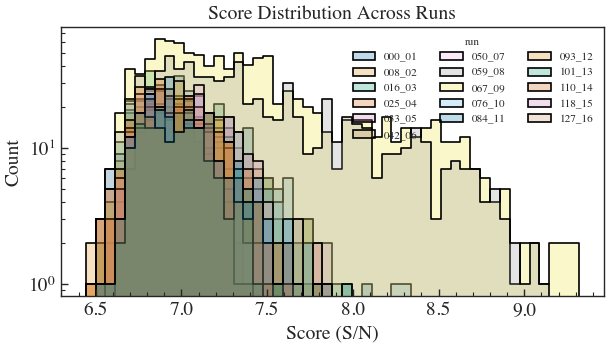

In [9]:
pgram.plot_scores(kind="hist", run_id=None)
plt.show()

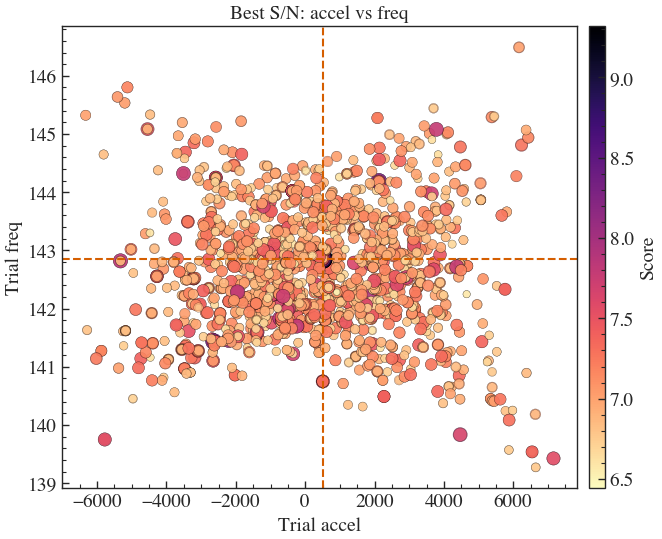

In [10]:
pgram.plot_correlation(
    "accel",
    "freq",
    true_values={"accel": cfg.mod_kwargs["acc"], "freq": cfg.freq},
    run_id=None,
)
plt.show()

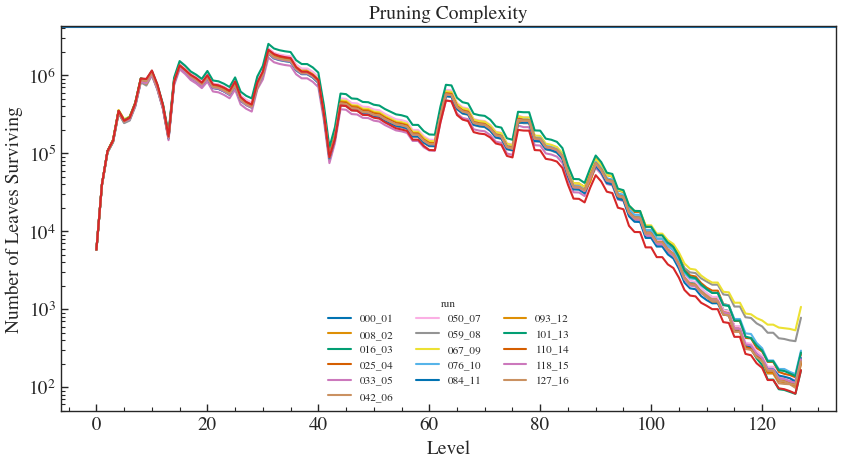

In [11]:
pstats = PruningStatsPlotter.load(result_file)
fig = pstats.plot_level_stats(run_id=None)
x = np.arange(0, len(branching_pattern) + 1)
ax_list = fig.axes
ax_list[0].plot(
    x,
    np.concatenate(([1], thresh_state.get_info("complexity"))) * dyp.nparam_vol,
    label="Expected",
    c="tab:red",
)
ax_list[0].axhline(2**22, label="RAM limit", c="tab:blue")
plt.show()